# Reproducibility and Analysis Overview

This notebook presents a reproducible time series analysis of the overall U.S. unemployment rate and the youth unemployment rate in the United States. The goal is to compare these two series in terms of volatility, cyclical behavior, and post-shock recovery over time using tools for time series analysis.

## Structure of the notebook

This notebook is organized to connect the code directly to the analytical questions being studied. Each major section includes brief narrative explanations describing the purpose of the analysis, the methods being applied, and how the results relate to the research question.

All preprocessing, analysis, and visualization steps needed to reproduce the results from the raw data are included here. The notebook documents how the data are obtained, cleaned, and preprocessed for time-series analysis. 

The notebook also includes appropriate diagnostic and validation steps for the methods used. These checks are included to ensure that conclusions are supported by the assumptions of the methods.

## Reseach question

How do unemployment dynamics differ across U.S. age groups in terms of volatility, persistence, and cyclical behavior over time? In this case, age groups are defined by the following age intervals: youth (16–24 yrs), prime (25-54 yrs), and older workers (55 yrs over). 

Here, we also define the following research goals:
Volatility: How much each unemployment series changes from month to month. In economics, this captures how sensitive each group is to expansions and recessions.
Persistence: How long do the effects of a labor market shock last once unemployment increases? In economics, this reflects how quickly displaced workers are reabsorbed. 
Cyclical Patterns: How each series behaves over business cycles. In economics, different cyclical patterns would suggest that youth and overall unemployment are affected differently by macroeconomic factors.

We also need to clearly define unemployment and unemployment rate here. Using the definition from the Bureau of Labor Statistics and Current Population Survey (CPS), a person is "unemployed" if the subject was not employed during the survey reference week and either actively looked for work during the last 4 weeks or was on temporary layoff. People waiting to start a new job are counted as unemployed only if they also looked for work in the last 4 weeks. The definition does not depend on whether someone receives unemployment insurance. And the unemployment rate is the number of unemployed people as a percentage of the labor force, where the labor force is employed + unemployed.

$$
\text{Unemployment Rate} = \frac{\text{Unemployed}}{\text{Labor Force}} \times 100
$$

I revised my initial question proposal to include other age groups based on the advide from Professor Liberty Hamilton's comment to address a richer question that, are labor-market dynamics different across age groups, rather than just between youth and the aggregate? The new, broader age-heterogeneity question avoids the weakness of using an aggregate as the only comparison and still fits the methods that I already planned out. I may still include the overall unemployment rate as a benchmark in descriptive plots, but the main analysis will focus on age-specific dynamics.

## Data

The data I will be using consists of four national monthly time series: the overall U.S. unemployment rate (UNRATE), the youth unemployment rate for ages 16–24 (LNS14024887), the prime-age workers unemployment rate for ages 25-54 (LNS14000060), and older workers unemployment rate for ages over 55 years old (LNS14024230), where the employment rate measures the share of the relevant labor force that is unemployed. All series come from the Current Population Survey (CPS), a monthly survey jointly sponsored by the U.S. Bureau of Labor Statistics and the U.S. Census Bureau. The data can be accessed through the Federal Reserve Economic Data (FRED) database. All series are seasonally adjusted and are reported as monthly percentages. Additionally, all series run from January 1948 to April 2026, giving 939 monthly observations. Thus, the analysis can use a matched sample of 940 time points for each series. In conclusion, our dataset contains four distinct but related time series observed at the same temporal resolution.

In the following code section, I will perform the data loading, cleaning, and preprocessing steps for time series analysis.

            overall  youth_16_24  prime_25_54  older_55_plus
date                                                        
1948-01-01      3.4          6.8          2.5            2.9
1948-02-01      3.8          7.7          2.9            3.1
1948-03-01      4.0          8.7          2.8            3.0
1948-04-01      3.9          7.8          3.0            3.0
1948-05-01      3.5          6.7          2.7            3.1
overall          1
youth_16_24      1
prime_25_54      1
older_55_plus    1
dtype: int64
Sample start: 1948-01-01 00:00:00
Sample end:   2026-04-01 00:00:00
Number of observations: 940
Missing timestamps relative to full monthly grid: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


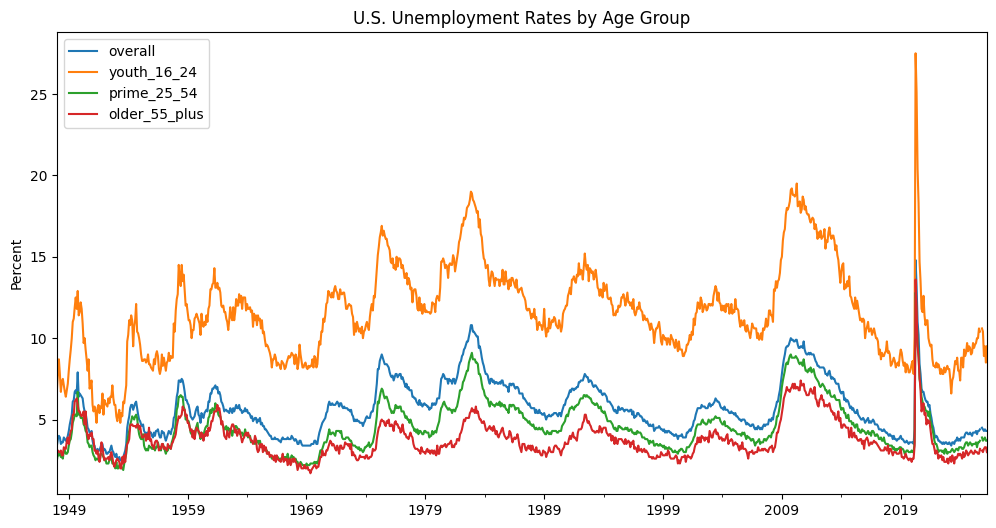

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the four datasets
overall = pd.read_csv("../data/UNRATE_overall.csv")
youth   = pd.read_csv("../data/UNRATE_youth.csv")
prime   = pd.read_csv("../data/UNRATE_prime.csv")
older   = pd.read_csv("../data/UNRATE_older.csv")


# rename columns
overall = overall.rename(columns={
    "observation_date": "date",
    "UNRATE": "overall"
})

youth = youth.rename(columns={
    "observation_date": "date",
    "LNS14024887": "youth_16_24"
})

prime = prime.rename(columns={
    "observation_date": "date",
    "LNS14000060": "prime_25_54"
})

older = older.rename(columns={
    "observation_date": "date",
    "LNS14024230": "older_55_plus"
})

for df in [overall, youth, prime, older]:
    df["date"] = pd.to_datetime(df["date"])
    df.sort_values("date", inplace=True)

# merge datasets
df = (
    overall
    .merge(youth, on="date", how="inner", validate="one_to_one")
    .merge(prime, on="date", how="inner", validate="one_to_one")
    .merge(older, on="date", how="inner", validate="one_to_one")
    .sort_values("date")
)

# set time index
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")

# set monthly frequency
df = df.asfreq("MS") 

# basic checks
print(df.head(5))
print(df.isna().sum())
print("Sample start:", df.index.min())
print("Sample end:  ", df.index.max())
print("Number of observations:", len(df))

expected_index = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Missing timestamps relative to full monthly grid:",

      expected_index.difference(df.index))

# visualization
df.plot(figsize=(12, 6))
plt.title("U.S. Unemployment Rates by Age Group")
plt.ylabel("Percent")
plt.xlabel("")
plt.show()

In [2]:
df[df.isna().any(axis=1)]

,overall,youth_16_24,prime_25_54,older_55_plus
date,,,,
2025-10-01,NaN,NaN,NaN,NaN


In [3]:
df = df.dropna()

expected_index = pd.date_range(df.index.min(), df.index.max(), freq="MS")
print("Missing timestamps relative to full monthly grid:",
      expected_index.difference(df.index))

Missing timestamps relative to full monthly grid: DatetimeIndex(['2025-10-01'], dtype='datetime64[ns]', freq='MS')


We loaded the four monthly unemployment-rate datasets for the overall labor force, youth workers, prime-age workers, and older workers from CSV files in the repo data folder, standardized the variable names, and converted the date column to a proper datetime format. We then merged the four files into a single dataframe by date, sorted the observations chronologically, and set the date variable as the time index so the data could be handled as monthly time series. After assigning an explicit monthly frequency, we checked for duplicate dates, missing values, and gaps in the monthly calendar. This revealed that October 2025 was missing for all four series, which reflects a genuine gap in the CPS source data rather than a coding error. BLS says CPS data were not collected for October 2025 due to the lapse in appropriations, were not collected retroactively, and no October 2025 Employment Situation release was issued. Because this month was not observed in the original data and our planned methods rely on the actual temporal dependence structure of the series, we dropped that month rather than imputing it, since filling it in artificially could distort spectral patterns, ARIMA dependence estimates, and lagged relationships. After removing that missing month, the series were aligned on a common sample from January 1948 to through April 2026 and were ready for downstream time-series analysis.